In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.DataLoader import load_propeller_dict

In [2]:
prop_name, blade_dict = load_propeller_dict('../Data/10x7E')[0]

In [3]:
rpm = 7000
n_rev_s = rpm / 60.0
diameter = 2 * blade_dict['tip_radius']

advance_ratios = np.arange(0, 1, 0.1)
v_inf_values = advance_ratios * n_rev_s * diameter

ct_values = []
cq_values = []
efficiency_values = []

for v_inf in v_inf_values:
    params = LowFidelityParameters(
        rpm=rpm,
        a_inf=343,
        rho=1.225,
        mu=1.81e-5,
        n_blades=blade_dict['n_blades'],
        p_ref=2e-5,
        revolutions=1,
        num_obs_times_per_rev=100,
        device='cpu',
    )
    
    propeller = Propeller(
        geometry=blade_dict,
        params=params,
        use_cuda_timing=False,
    )
    
    propeller.run_bemt(v_inf=v_inf)
    thrust, torque, ct, cq = propeller.compute_total_forces()
    
    ct_values.append(ct)
    cq_values.append(cq)
    
    J = v_inf / (n_rev_s * diameter) if n_rev_s * diameter > 0 else 0
    eta = (J * ct / cq / 2 / np.pi) if cq > 0 else 0
    efficiency_values.append(eta)
    
    print(f'J = {J:.3f}, CT = {ct:.4f}, CQ = {cq:.5f}, η = {eta:.3f}')

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


J = 0.000, CT = 0.1161, CQ = 0.00763, η = 0.000


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


J = 0.100, CT = 0.1188, CQ = 0.00847, η = 0.223


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


...

J = 0.700, CT = 0.0209, CQ = 0.00351, η = 0.665


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


J = 0.800, CT = -0.0050, CQ = 0.00063, η = -1.005


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


J = 0.900, CT = -0.0322, CQ = -0.00246, η = 0.000


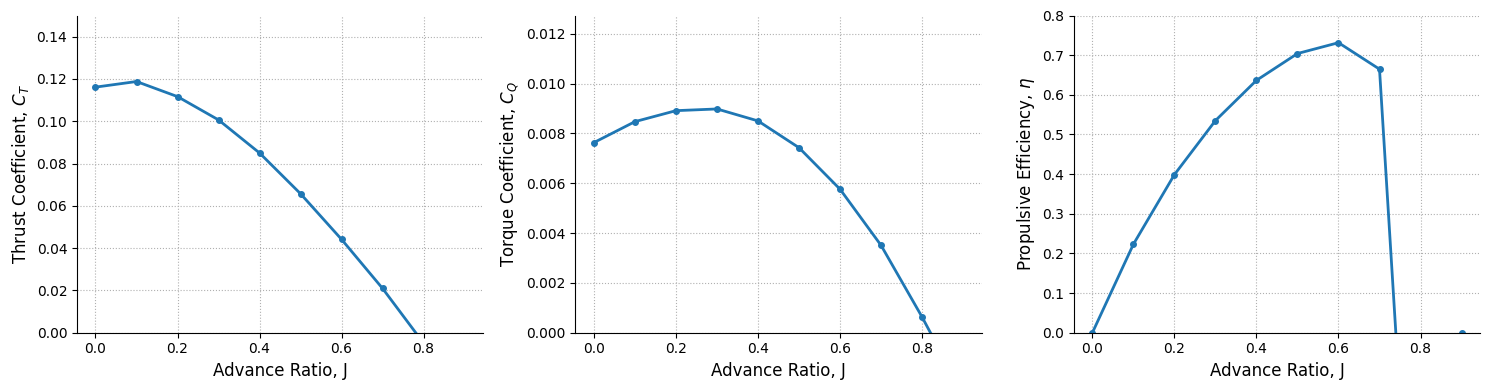

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(advance_ratios, ct_values, 'o-', linewidth=2, markersize=4)
axes[0].set_xlabel('Advance Ratio, J', fontsize=12)
axes[0].set_ylabel('Thrust Coefficient, $C_T$', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=1.0)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(top=False, right=False, which='both')
axes[0].set_ylim(0, 0.15)

axes[1].plot(advance_ratios, cq_values, 'o-', linewidth=2, markersize=4)
axes[1].set_xlabel('Advance Ratio, J', fontsize=12)
axes[1].set_ylabel('Torque Coefficient, $C_Q$', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=1.0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(top=False, right=False, which='both')
axes[1].set_ylim(0, 0.08/ 2 / np.pi)

axes[2].plot(advance_ratios, efficiency_values, 'o-', linewidth=2, markersize=4)
axes[2].set_xlabel('Advance Ratio, J', fontsize=12)
axes[2].set_ylabel('Propulsive Efficiency, $\\eta$', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=1.0)
axes[2].spines[['top', 'right']].set_visible(False)
axes[2].tick_params(top=False, right=False, which='both')
axes[2].set_ylim(0, 0.8)

plt.tight_layout()
plt.savefig('../Figures/Validation/bemt_performance.pdf', dpi=200)
plt.show()